In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import astropy
import scipy.stats
from scipy.stats import norm, lognorm
from scipy.stats import uniform
from astroML import stats as astroMLstats
import math
from scipy.optimize import minimize

import scipy.optimize as optimize

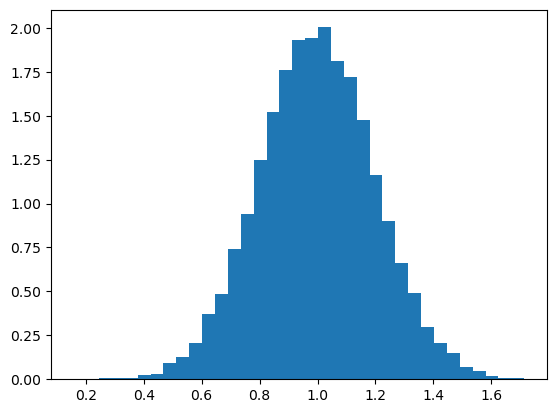

In [2]:
mu = 1
sigma = 0.2
N = 10000
Nbins = 35

# true distribution:
distGauss = scipy.stats.norm(loc=mu, scale=sigma)
plt.hist(distGauss.rvs(N), density=True, bins=Nbins)

# fake points:
fake = []
distG = scipy.stats.norm(loc=mu, scale=sigma)
fake = distG.rvs(N)

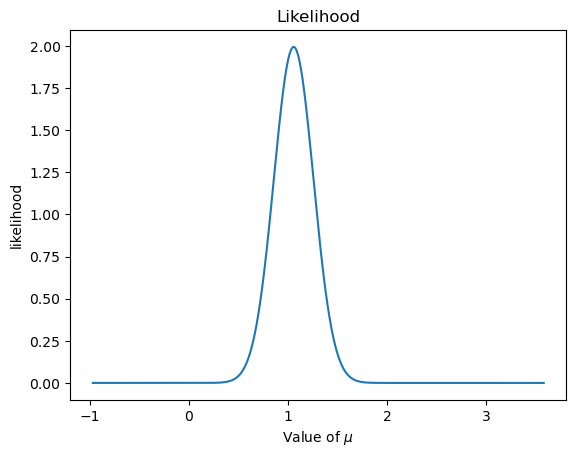

In [3]:
Mu = []
fakeMin = min(fake)
fakeMax = max(fake)

Mu = np.linspace(-4.2*fakeMin, 2*fakeMax, N)
f_mu = norm.pdf(fake[3], loc=Mu, scale=sigma)

plt.plot(Mu, f_mu)
plt.title("Likelihood")
plt.xlabel("Value of $\mu$")
plt.ylabel("likelihood")
plt.show()

Estimate:  1.0041711000156368
MLE:  1.0041711075287527


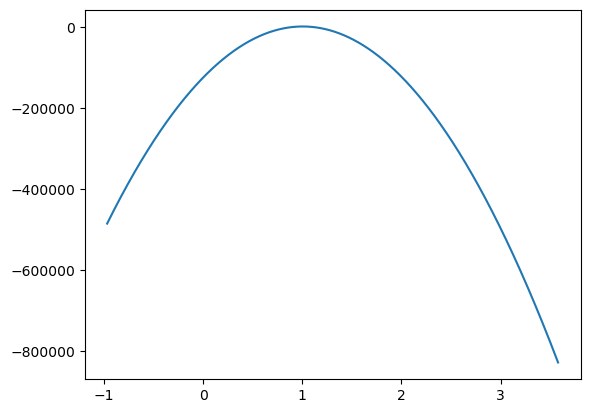

In [4]:
def log_likelihood(mu, data, sigma):
    log_likel = -0.5*np.sum(np.log(2*np.pi*sigma**2) + ((data - mu)/sigma)** 2)
    return log_likel

# initial estimate for the mean value
initial_guess = 1

# maximize the logarithm of the likelihood
result = minimize(lambda MU: -log_likelihood(MU, fake, sigma), initial_guess)

estimated_mu = result.x[0]

print("Estimate: ", estimated_mu)
print("MLE: ", np.sum(fake)/N)

log_likelihoods = [log_likelihood(y, fake, sigma) for y in Mu]

plt.plot(Mu, log_likelihoods)
plt.show()

In [5]:
Fisher = np.sqrt(N*np.sum(-np.diff(log_likelihoods, n=2)/(Mu.max()-Mu.min())**2)) # why is there a N?
trueFisher = np.sqrt(N/sigma**2)

print(trueFisher, Fisher)

499.99999999999994 499.99999749946215
